# 실전 마케팅 데이터 AARRR 퍼널 분석

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [50]:
# 한글 폰트 및 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [51]:
df = pd.read_csv("data/Market_data.csv", encoding="euc-kr")
df

# Channel: 유입 채널(Organic: 자연유입, Paid_Social: SNS유료광고, Influencer: 인플루언서 마케팅)
# Ad_Spend: 고객 1인당 광고비
# UI_Group: 고객이 경험한 결제 페이지 UI(UI_A: 기존 화면, UI_B: 이번에 새로 개발한 화면)
# First_Purchase: 첫 구매액 (결제 페이지 UI의 성과를 판단하는 지표)
# Time_Before_Promo: 프로모션(쿠폰/푸시알림 등)을 진행하기 전, 고객의 평균 앱(웹) 체류시간(분)
# Time_After_Promo: 프로모션 진행후 평균 체류시간
# Referral_Count: 해당 고객이 친구 초대 및 링크 공유 등을 통해 타인을 추천한 횟수
# Total_Revenue: 해당 고객이 우리 서비스에서 결제한 누적 총 매출

# Acquired: 1단계[획득] - 우리 서비스에 방문했는가? (본 실습에서는 전원 1(방문함)로 간주)
# Activated: 2단계[활성화] - 첫 구매액이 2만원 이상인가? (우리가 설정한 활성화 기준)
# Retained: 3단계[유지] - 프로모션 이후 앱 체류시간이 18분 이상인가? (충성고객 판단)
# Referred: 4단계[추천] - 주변에 1명 이상 추천(친구 초대)을 했는가?
# Revenue_Generated: 5단계[수익] - 누적 총 매출이 8만원을 넘는 고객인가? (VIP 판단)

,Customer_ID,Channel,Ad_Spend,UI_Group,First_Purchase,Time_Before_Promo,Time_After_Promo,Referral_Count,Total_Revenue,Acquired,Activated,Retained,Referred,Revenue_Generated
0,1,Organic,6059.936384,UI_A(기존),41196.877786,10.388243,11.843945,2,72462.645407,1,1,0,0,0
1,2,Influencer,16851.017849,UI_B(신규),35830.531623,10.903066,15.209803,0,64326.925847,1,1,0,0,0
2,3,Paid_Social,28417.846616,UI_B(신규),29606.888129,9.055294,9.912905,0,75761.780046,1,1,0,0,0
3,4,Paid_Social,18170.221444,UI_A(기존),29586.627952,17.208803,22.875224,2,81958.694879,1,1,1,1,1
4,5,Organic,6211.943985,UI_A(기존),30195.996166,15.878018,20.382111,2,71621.944776,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Influencer,20024.579019,UI_A(기존),25953.041431,14.556969,17.939854,1,78256.753432,1,1,0,0,0
2996,2997,Organic,4725.197695,UI_B(신규),43296.043614,15.015990,18.029839,1,83548.076291,1,1,1,1,1
2997,2998,Organic,2798.756527,UI_A(기존),49824.704502,12.375703,13.528844,2,70928.562793,1,1,0,0,0
2998,2999,Organic,3001.111093,UI_A(기존),39537.602558,10.250021,8.686697,2,48404.635240,1,1,0,0,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        3000 non-null   int64  
 1   Channel            3000 non-null   object 
 2   Ad_Spend           3000 non-null   float64
 3   UI_Group           3000 non-null   object 
 4   First_Purchase     3000 non-null   float64
 5   Time_Before_Promo  3000 non-null   float64
 6   Time_After_Promo   3000 non-null   float64
 7   Referral_Count     3000 non-null   int64  
 8   Total_Revenue      3000 non-null   float64
 9   Acquired           3000 non-null   int64  
 10  Activated          3000 non-null   int64  
 11  Retained           3000 non-null   int64  
 12  Referred           3000 non-null   int64  
 13  Revenue_Generated  3000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 328.3+ KB


## 주요 컬럼 시각화

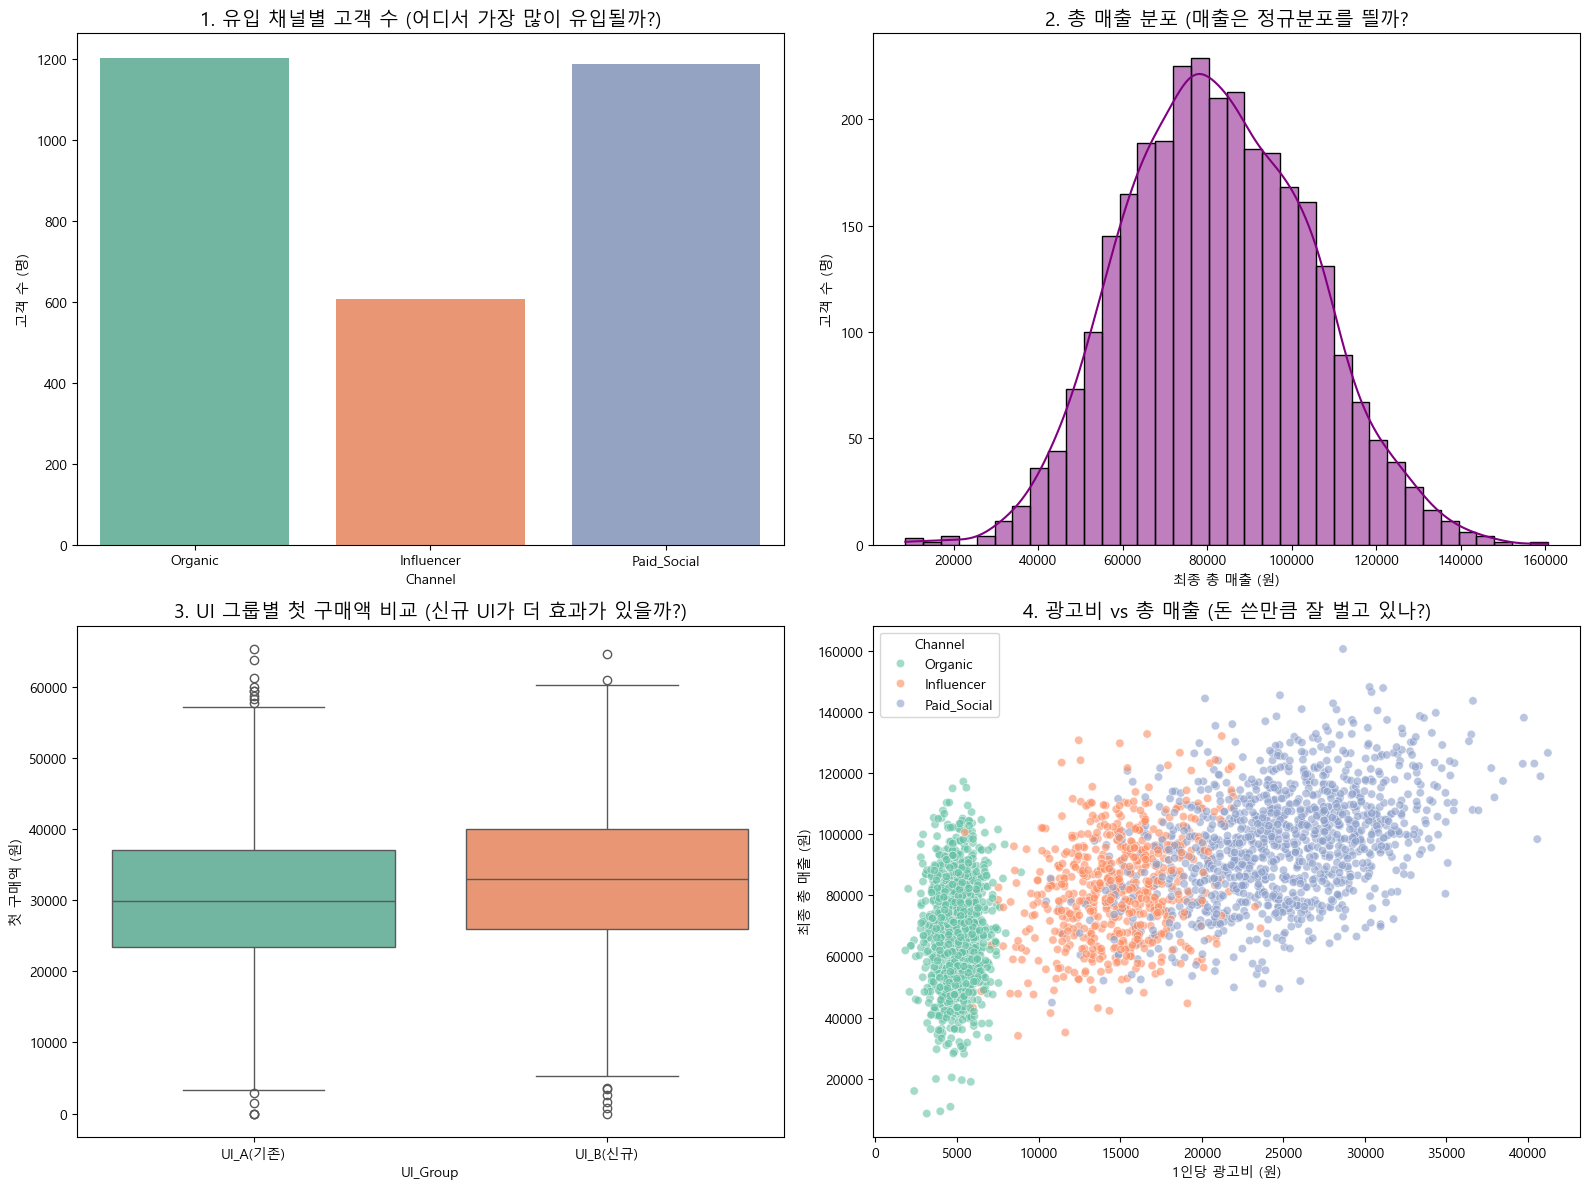

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. 유입 채널별 고객 수
sns.countplot(data=df, x="Channel", palette="Set2", hue="Channel", ax=axes[0,0])
axes[0,0].set_title("1. 유입 채널별 고객 수 (어디서 가장 많이 유입될까?)", fontsize=14)
axes[0,0].set_ylabel("고객 수 (명)")

# 2. 총 매출 분포
sns.histplot(data=df, x="Total_Revenue", kde=True, color="purple", ax=axes[0,1])
axes[0,1].set_title("2. 총 매출 분포 (매출은 정규분포를 띌까?", fontsize=14)
axes[0,1].set_xlabel("최종 총 매출 (원)")
axes[0,1].set_ylabel("고객 수 (명)")

# 3. UI 그룹별 첫 구매액 비교
sns.boxplot(data=df, x="UI_Group", y="First_Purchase", hue="UI_Group", palette="Set2", ax=axes[1,0])
axes[1,0].set_title("3. UI 그룹별 첫 구매액 비교 (신규 UI가 더 효과가 있을까?)", fontsize=14)
axes[1,0].set_ylabel("첫 구매액 (원)")

# 4. 광고비 vs 총 매출 산점도
sns.scatterplot(data=df, x="Ad_Spend", y="Total_Revenue", hue="Channel", palette="Set2", alpha=0.6, ax=axes[1,1])
axes[1,1].set_title("4. 광고비 vs 총 매출 (돈 쓴만큼 잘 벌고 있나?)", fontsize=14)
axes[1,1].set_xlabel("1인당 광고비 (원)")
axes[1,1].set_ylabel("최종 총 매출 (원)")

plt.tight_layout()
plt.show()

- 유입 채널별 고객수를 보면 Organic(자연유입)과 Paid_Social(SNS광고)이 비슷하다고 두 채널에 예산을 똑같이 쓰는게 아니라, <mark>누가 돈을 더 많이 쓰는가가 중요</mark>하므로 확인해봐야함 - **ANOVA분석**
- 고객들의 최종 결제액이 정규분포인지 비대칭인지 확인하고, 정규분포이므로 중간에 있는 <mark>평범한 고객들을 어떻게 오른쪽 VIP영역으로 끌고 올 것인지</mark> 고민해야함 - **마케팅 전략 고민**
- 화면 UI별로 첫 구매액은 신규 UI가 약간 더 좋아보이지만 꼬리부분을 보면 꽤 비슷하므로 <mark>이 차이가 UI때문인지 아니면 우연인지</mark> 확인해야 함 - **T-test**
- 광고비-매출 산점도에서 양의 상관관계로 보이는데 <mark>실제로 광고비를 얼마 더 투입하면 얼마의 매출이 늘어날지</mark> 계산해봐야 함 - **선형회귀분석**

## Step1. Acquisition(획득): 고객이 어떻게 유입되었는가?
- 현재는 이미 유입된 고객들의 데이터로 진행중이므로 클릭률(광고를 본 사람 대비 몇 명이나 우리 사이트에 들어왔는지)을 알 수는 없음
- 단, 유입된 사람들이 어떤 채널을 통해 유입됐고, 그 한명을 데려오기 위해 마케팅 비용을 얼마나 썼는지(CAC)는 구해볼 수 있음
- **CAC(고객획득비용)**: `총 마케팅 비용 / 신규 고객수`

In [54]:
df.head()

,Customer_ID,Channel,Ad_Spend,UI_Group,First_Purchase,Time_Before_Promo,Time_After_Promo,Referral_Count,Total_Revenue,Acquired,Activated,Retained,Referred,Revenue_Generated
0,1,Organic,6059.936384,UI_A(기존),41196.877786,10.388243,11.843945,2,72462.645407,1,1,0,0,0
1,2,Influencer,16851.017849,UI_B(신규),35830.531623,10.903066,15.209803,0,64326.925847,1,1,0,0,0
2,3,Paid_Social,28417.846616,UI_B(신규),29606.888129,9.055294,9.912905,0,75761.780046,1,1,0,0,0
3,4,Paid_Social,18170.221444,UI_A(기존),29586.627952,17.208803,22.875224,2,81958.694879,1,1,1,1,1
4,5,Organic,6211.943985,UI_A(기존),30195.996166,15.878018,20.382111,2,71621.944776,1,1,1,1,0


In [55]:
# CAC 계산을 위해 유입 채널별 총 광고비와 유입된 고객수 출력하기
 # agg: 컬럼별로 다른 집계함수 적용
acq_df = df.groupby("Channel").agg(
    # 새 컬럼명=(기존 컬럼명, 집계함수)
    Total_Spend=("Ad_Spend", "sum"),     # 채널별 총 광고(마케) 비용
    Custormers=("Customer_ID", "count")  # 채널별 유입 고객 수
).reset_index()

# style.format: 특정 컬럼의 출력 결과 형식 지정
acq_df.style.format({"Total_Spend": "{:,.0f}"})

,Channel,Total_Spend,Custormers
0,Influencer,"9,030,019",608
1,Organic,"6,001,537",1204
2,Paid_Social,"29,643,658",1188


In [56]:
# CAC 계산해서 DF에 추가
acq_df["CAC"] = acq_df["Total_Spend"] / acq_df["Custormers"]
acq_df

,Channel,Total_Spend,Custormers,CAC
0,Influencer,9.030019e+06,608,14852.004461
1,Organic,6.001537e+06,1204,4984.665042
2,Paid_Social,2.964366e+07,1188,24952.574442


In [58]:
display_df = acq_df.style.format({
    "Total_Spend": "{:,.0f}원",
    "Custormers": "{:,.0f}명",
    "CAC": "{:,.0f}원"
})
display_df

,Channel,Total_Spend,Custormers,CAC
0,Influencer,"9,030,019원",608명,"14,852원"
1,Organic,"6,001,537원","1,204명","4,985원"
2,Paid_Social,"29,643,658원","1,188명","24,953원"


- CAC(고객획득비용)이 가장 적은 채널은 Organic(자연유입)이며, 가장 큰 채널은 paid_Social(SNS홍보)임
- <mark>CAC가 낮다고 무조건 Organic에만 집중하면 안되고, 실제로 해당 고객들이 결제를 더 많이 하는지</mark>를 따져봐야함

## Step2. Activation(활성화): 신규 UI(B)가 고객의 첫 구매액을 늘렸을까?

In [59]:
# 사이트의 기존 UI와 신규 UI별 첫 구매액으로 두 그룹으로 분리
group_a = df[df["UI_Group"] == "UI_A(기존)"]["First_Purchase"]
group_b = df[df["UI_Group"] == "UI_B(신규)"]["First_Purchase"]

print(f"▶ UI_A(기존) 첫 구매액 평균:{group_a.mean():,.0f}원")
print(f"▶ UI_B(신규) 첫 구매액 평균:{group_b.mean():,.0f}원")

# 독립표본 t-test 수행
_, p_value = stats.ttest_ind(group_a, group_b, equal_var = False)

print(f"▶ 유의확율(p-value):{p_value:,.4f}")

print("\n[비즈니스 인사이트]")
if p_value < 0.05:
    print(" - p-value가 0.05 미만으로, 두 UI간의 첫 구매액 차이는 통계적으로 유의미합니다.")
    print(" - 액션플랜 : 신규 UI가 결제 활성화에 더 효과적이므로 전면 도입을 검토하세요")
else:
    print(" - p-value가 0.05 이상으로, 구매액 차이는 우연일 가능성이 높습니다.")
    print(" - 액션플랜 : 신규 UI 개발 비용 대비 효과가 불분명하므로, 기존 UI를 유지하거나 재설계하세요.")

▶ UI_A(기존) 첫 구매액 평균:30,211원
▶ UI_B(신규) 첫 구매액 평균:32,957원
▶ 유의확율(p-value):0.0000

[비즈니스 인사이트]
 - p-value가 0.05 미만으로, 두 UI간의 첫 구매액 차이는 통계적으로 유의미합니다.
 - 액션플랜 : 신규 UI가 결제 활성화에 더 효과적이므로 전면 도입을 검토하세요


## Step3. Retetion(유지): 재방문 유도 프로모션이 체류시간을 늘렸을까?

In [60]:
# 프로모션 전후 체류시간 출력
print(f"▶ 프로모션 전 평균 체류시간:{df["Time_Before_Promo"].mean():.1f}분")
print(f"▶ 프로모션 후 평균 체류시간:{df["Time_After_Promo"].mean():.1f}분")


# 대응표본 t-test(동일한 고객의 프로모션 전/후의 체류시간 평균 비교)
_, p_value_rel = stats.ttest_rel(df["Time_Before_Promo"],df["Time_After_Promo"])

print(f"\n▶ p-value: {p_value_rel:.4f}")

print("\n[비즈니스 인사이트]")
if p_value_rel < 0.05:
    print(" - p-value가 0.05미만 이므로, 프로모션 전후의 페류시간 변화는 확실한 팩트입니다.")
    print(" - 액션플랜 : 프로모션이 고객 유지 방어에 성공했습니다. 정기 캠페인으로 편성하세요.")
else:
    print(" - 체류시간 변화가 유의미하지 않습니다. 프로모션 기획을 전면 수정하세요.")

▶ 프로모션 전 평균 체류시간:14.9분
▶ 프로모션 후 평균 체류시간:18.0분

▶ p-value: 0.0000

[비즈니스 인사이트]
 - p-value가 0.05미만 이므로, 프로모션 전후의 페류시간 변화는 확실한 팩트입니다.
 - 액션플랜 : 프로모션이 고객 유지 방어에 성공했습니다. 정기 캠페인으로 편성하세요.


## Step4. Revenue(수익): 어떤 유입 채널의 고객이 가장 돈을 많이 쓸까?
- **CLV(고객생애가치)**: `평균구매액 * 구매빈도 / 이탈률`

### 1) 채널별 평균 매출액 계산 및 ANOVA 분석
- 구매빈도는 생략해도 되는 것이 Total_Revenue가 해당 고객이 우리 서비스에서 결제한 '누적 총 매출액'이므로 이미 빈도가 반영되어 있기 때문

In [61]:
# 채널별 총 매출액(고객 구매액) 분리
organic = df[df["Channel"] == "Organic"]["Total_Revenue"]
paid = df[df["Channel"] == "Paid_Social"]["Total_Revenue"]
influencer = df[df["Channel"] == "Influencer"]["Total_Revenue"]

# 채널별 평균 매출액(구매빈도 포함)
organic_arpu = organic.mean()
paid_arpu = paid.mean()
influencer_arpu = influencer.mean()

print(f"▶ Organic 평균 매출:{organic_arpu:,.0f}원")
print(f"▶ Paid 평균 매출:{paid_arpu:,.0f}원")
print(f"▶ Influencer 평균 매출:{influencer_arpu:,.0f}원")

▶ Organic 평균 매출:67,829원
▶ Paid 평균 매출:97,167원
▶ Influencer 평균 매출:82,411원


In [62]:
# ANOVA - 세 집단 이상의 평균 비교
_, p_value_anova = stats.f_oneway(organic, paid, influencer)
print(f"▶ p-value: {p_value_anova:.4f}")

▶ p-value: 0.0000


- 유입 채널에 따라 고객의 최종 평균 매출에 확실한 차이가 존재함
- 그러나 고객 이탈률을 반영한 CLV까지 따져보고 결정해야함

### 2) 채널별 CLV 계산
- 이탈률 1에서 유지율을 뺀 값이므로 유지율을 먼저 구해야함

In [63]:
# 채널별 유지율 계산
# 'Retained' 컬럼(1:유지, 0:이탈)의 평균을 구하면 그게 바로 유지율이 됨
retention_rates = df.groupby("Channel")["Retained"].mean()
retention_rates

Channel
Influencer     0.419408
Organic        0.446013
Paid_Social    0.431818
Name: Retained, dtype: float64

In [64]:
# 채널별 이탈률 계산(1-유지율)
 # 이탈률이 0이 되면 수학 계산이 불가하므로 최소 이탈률을 0.01(1%)로 보장시켜서 계산
# 이탈률이 0이되면 안되기 때문에 0.01을 넣음
organic_churn = max(1 - retention_rates["Organic"], 0.01)
paid_churn = max(1 - retention_rates["Paid_Social"], 0.01)
influencer_churn = max(1 - retention_rates["Influencer"], 0.01)

# 채널별 CLV 구하기
organic_clv = organic_arpu / organic_churn
paid_clv = paid_arpu / paid_churn
influencer_clv = influencer_arpu  / influencer_churn

print(f"Organic ClV    : {organic_clv:,.0f}원 (이탈률: {organic_churn:,.4f})")
print(f"Paid_Social ClV: {paid_clv:,.0f}원 (이탈률: {paid_churn:,.4f})")
print(f"Influencer ClV : {influencer_clv:,.0f}원 (이탈률: {influencer_churn:,.4f})")

Organic ClV    : 122,437원 (이탈률: 0.5540)
Paid_Social ClV: 171,014원 (이탈률: 0.5682)
Influencer ClV : 141,943원 (이탈률: 0.5806)


### 3) 고객획득비용(CAC)을 반영한 유입채널별 최종 ROI 구하기
- ROI(Return on Investment): 투자 대비 이익

In [65]:
acq_df

,Channel,Total_Spend,Custormers,CAC
0,Influencer,9.030019e+06,608,14852.004461
1,Organic,6.001537e+06,1204,4984.665042
2,Paid_Social,2.964366e+07,1188,24952.574442


In [66]:
organic_cac = acq_df.loc[acq_df["Channel"] =="Organic","CAC"].values[0]
paid_cac = acq_df.loc[acq_df["Channel"] =="Paid_Social","CAC"].values[0]
influencer_cac = acq_df.loc[acq_df["Channel"] =="Influencer","CAC"].values[0]

print(f"Organic ROI: {organic_clv / organic_cac:.1f}배")
print(f"Paid ROI: {paid_clv / paid_cac:.1f}배")
print(f"Influencer ROI: {influencer_clv / influencer_cac:.1f}배")

Organic ROI: 24.6배
Paid ROI: 6.9배
Influencer ROI: 9.6배


#### 비즈니스 인사이트
1) **겉보기 매출의 함정**: 초기 평균 매출(ARPU)만 봤을때는 Paid_Social이 1등이었지만, 고객유입비용(CAC)를 고려한 최종 ROI는 Organic이 압도적 1위
2) **예산 분배 전략**: 무작정 유료 광고(Paid) 예산을 늘리기보다, 가성비가 가장 좋은 자연유입(Organic) 볼륨을 키우기 위해 블로그 활성화 및 검색엔진 최적화, 자체 컨텐츠 개발에 투자하는 것이 좋음
3) **리텐션(유지)의 중요성**: 이탈률을 반영하여 CLV를 구하니 고객의 가치가 달라질 수 있으며, 마케팅의 끝은 유이입 아니라 유지라서 이탈률이 큰 그룹이 있다면 이를 잘 막는것도 중요함

## Step5. Referral(추천) & Revenue: 광고비와 추천이 매출에 미치는 상관성 및 정확한 공식 찾기


#### 1) 상관분석
- '추천횟수'와'최종매출'간 상관성 확인

In [68]:
corr, p_corr = stats.pearsonr(df["Referral_Count"], df["Total_Revenue"])
print(f"▶ 추천횟수와 매출의 상관계수(r): {corr:.4f} (p-value: {p_corr:.4f})")

# 복잡한 사람의 심리가 많이 반영된 마케팅 데이터에서는 상관계수가 0.3이면 꽤나 유의미한 상관성이 있다고 봄
# 즉, 주변에 추천을 많이 하는 고객들은 본인들도 우리의 상품(서비스)에 대해 만족하고 돈을 꽤 쓴다고 볼 수 있음

▶ 추천횟수와 매출의 상관계수(r): 0.3264 (p-value: 0.0000)


#### 2) 선형회기 분석
- Paid_Scocial 채널의 광고비 vs 매출 예측
- 유료광고는 투입한 돈 대비 매출이 인과관계가 있기 때문에 선형회귀 분석이 가능하지만, 자연유입은 블로그에 글을 쓰거나 검색 엔진 최적화를 세팅한 마케터의 인건비와 유지비가 녹아 있어 회귀분석이 애매함
- 우리는 유료광고 중 가장 유입이 많은 Paid_Social과 매출의 관계를 선형회귀 분석을 통해 예측해보자!

In [69]:
paid_df = df[df["Channel"] == "Paid_Social"]
paid_df.head(3)

,Customer_ID,Channel,Ad_Spend,UI_Group,First_Purchase,Time_Before_Promo,Time_After_Promo,Referral_Count,Total_Revenue,Acquired,Activated,Retained,Referred,Revenue_Generated
2,3,Paid_Social,28417.846616,UI_B(신규),29606.888129,9.055294,9.912905,0,75761.780046,1,1,0,0,0
3,4,Paid_Social,18170.221444,UI_A(기존),29586.627952,17.208803,22.875224,2,81958.694879,1,1,1,1,1
8,9,Paid_Social,16118.823836,UI_B(신규),48404.412398,7.371688,10.911857,2,64177.064961,1,1,0,0,0


In [39]:
reg = stats.linregress(paid_df["Ad_Spend"], paid_df["Total_Revenue"])
r_squared = reg.rvalue ** 2   # 회귀결정계수

print("▶ [Paid_Social 채널 매출 예측 공식]")
print(f" - 예측 매출 = ({reg.slope:.2f} x 광고비) + {reg.intercept:,.0f}원")
print(f" - 회귀결정계수(R^2): {r_squared * 100:.1f}%")
print(f" - p-value: {reg.pvalue:.4f}")

▶ [Paid_Social 채널 매출 예측 공식]
 - 예측 매출 = (1.52 x 광고비) + 59,335원
 - 회귀결정계수(R^2): 17.6%
 - p-value: 0.0000


## Step6. AARRR 퍼널 시각화를 통해 병목 구간 찾기

In [70]:
# 각 단계별 전환 유저수 계산
funnel_data = {
    'Stage': ['1. Acquisition (방문)',
              '2. Activation (첫 구매)',
              '3. Retention (재방문)',
              '4. Referral (추천)',
              '5. Revenue (결제)'
    ],
    'Users': [
        df['Acquired'].sum(),
        df['Activated'].sum(),
        df['Retained'].sum(),
        df['Referred'].sum(),
        df['Revenue_Generated'].sum()
    ]
}
funnel_df = pd.DataFrame(funnel_data)
funnel_df

,Stage,Users
0,1. Acquisition (방문),3000
1,2. Activation (첫 구매),2614
2,3. Retention (재방문),1305
3,4. Referral (추천),1146
4,5. Revenue (결제),630


In [71]:
# 전환율 계산: 이전 단계 대비 몇 %가 유입됐는가?
funnel_df["Conversion_Rate(%)"] = (funnel_df["Users"] / funnel_df["Users"].shift(1) * 100).fillna(100)
funnel_df

,Stage,Users,Conversion_Rate(%)
0,1. Acquisition (방문),3000,100.000000
1,2. Activation (첫 구매),2614,87.133333
2,3. Retention (재방문),1305,49.923489
3,4. Referral (추천),1146,87.816092
4,5. Revenue (결제),630,54.973822


In [72]:
funnel_df["Users"].shift(1) # 인덱스가 내려감(이전단계로 내려감)

0       NaN
1    3000.0
2    2614.0
3    1305.0
4    1146.0
Name: Users, dtype: float64

### plotly 라이브러리 활용 퍼널 시각화
- 정적 시각화 라이브러리(matplotlib, seaborn)가 아닌 동적 시각화 라이브러리로 툴팁, 줌인아웃, 특정그룹 확인 등의 기능을 활용할 수 있음

In [45]:
!pip install plotly

In [73]:
# grah_object: 시각화 요소들을 커스터마이징 가능하게 해주는 클래스
import plotly.graph_objects as go

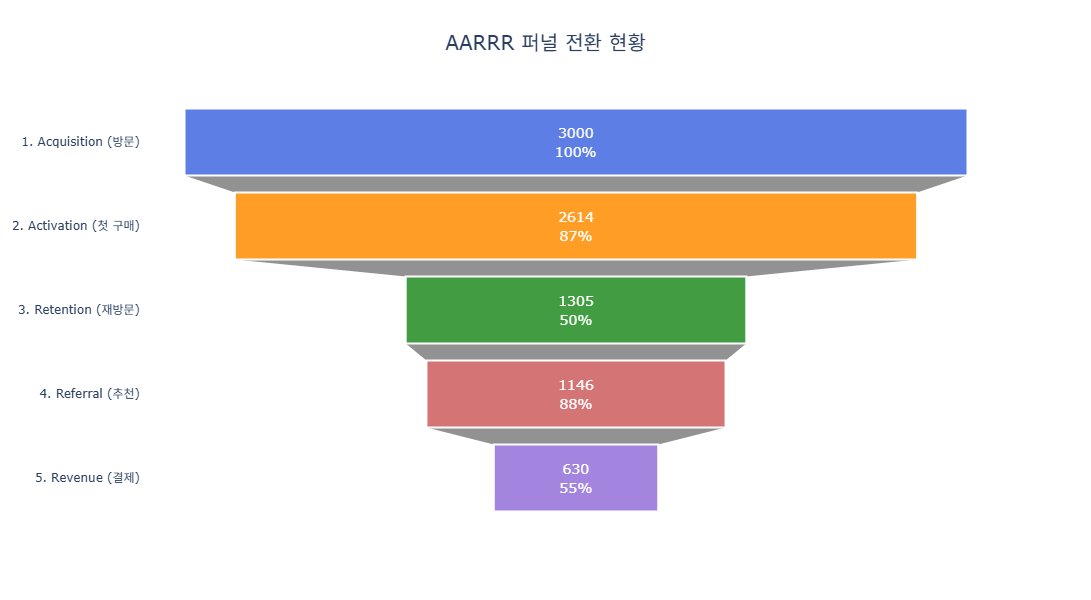

In [74]:
# Figure: 시각화 내용을 넣을 그래프 형태(틀) 생성
fig = go.Figure(
    # Funnel: 퍼널(깔때기 형태) 차트 형성
    go.Funnel(
        x = funnel_df["Users"],
        y = funnel_df["Stage"],

        # textinfo: 막대 위에 표시할 정보의 종류
        #            "실제값(value) + 이전 단계 대비 현재 단계 비율(percent previous)"을 알아서 계산
        textinfo = "value+percent previous",    # +기호로 조합해서 사용가능
        # (종류는 공식페이지 참조: https://plotly.com/python/reference/funnel/)

        opacity = 0.85,  # 투명도 설정

        # 막대 스타일
        marker = {
            # 막대 색상
            "color": ["royalblue", "darkorange", "forestgreen", "indianred", "mediumpurple"],
            # 막대 테두리 선
            "line": {
                "width": [2, 2, 2, 2, 2], 
                "color": ["white", "white", "white", "white", "white"]
            }
        },

        # 글씨 크기 및 폰트 설정
        textfont = {"size": 14, "color": "white"}
    )
)
# 차트 제목 및 레이아웃 설정
fig.update_layout(
    title_text = "AARRR 퍼널 전환 현황",
    title_x = 0.5,  # 제목의 x축 위치(0~1로 상대적인 위치 설정, 0.5면 중앙이라는 뜻)
    title_font_size = 20,   #제목 폰트 크기
    plot_bgcolor = "white", # 차트 배경색 지정
    width = 800,
    height = 600
)

fig.show()